# 01 · Rigid-Body Motions and Screw Axis Theory

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boelnasr/ManipulaPy/blob/notebooks/tutorials/notebooks/01_rigid_body_motions.ipynb)

> **ManipulaPy teaching course — notebook 1 of 11.** Running robot: Franka Panda.

This is where the whole course begins. Every later notebook — forward kinematics, Jacobians, dynamics, control — is built on the language introduced here. We build it from the ground up:

1. **Rotations** and the group $SO(3)$
2. **Angular velocity** and exponential coordinates for rotation
3. **Rigid-body motions** and the group $SE(3)$
4. **Screw axes** and **twists**
5. **Exponential coordinates** for rigid-body motion
6. The **adjoint map** for changing the frame of a twist

Throughout, the concepts are demonstrated with the matching functions in `ManipulaPy.utils`.

### Running on Colab or another cloud platform?

The next cell bootstraps the environment when it detects Google Colab: it clones the repository (so the shared helpers and figure sources are available) and installs ManipulaPy. It is a **no-op when you run locally** from a clone of the repo. Figures are pre-rendered and committed, so they display even without a TeX installation — install TeX Live + poppler only if you want to re-render them from the `.tex` sources.

In [1]:
# Cloud bootstrap (no-op when running locally from the repo).
import sys
if "google.colab" in sys.modules:
    !git clone -q https://github.com/boelnasr/ManipulaPy.git
    %cd ManipulaPy/notebooks
    !pip install -q -e ..
    print("Colab setup complete.")

In [2]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), "_shared"))
from tikz import render_tikz_file, setup_pgf, embed_pgf_fig
import numpy as np
from ManipulaPy.utils import (
    MatrixExp3, MatrixLog3, MatrixExp6, MatrixLog6,
    VecToso3, VecTose3, se3ToVec, skew_symmetric_to_vector,
    adjoint_transform, TransInv, TransToRp,
    rotation_logm, transform_from_twist, extract_screw_list,
    euler_to_rotation_matrix, rotation_matrix_to_euler_angles,
)
np.set_printoptions(precision=4, suppress=True)
print("imports OK")

🤖 ManipulaPy v1.3.2.post1 loaded (lazy imports enabled)
   💡 Use ManipulaPy.check_dependencies() to see available features
imports OK


## 1. Rotations and $SO(3)$

A **rotation matrix** $R$ describes the orientation of one frame relative to another. The set of all rotations forms the **special orthogonal group** $SO(3)=\{R\in\mathbb{R}^{3\times3}\mid R^\top R=I,\ \det R=+1\}$. The two defining properties — orthonormal columns and determinant $+1$ — mean a rotation preserves lengths, angles, and handedness.

The figure below shows a body frame $\{b\}$ obtained by rotating the fixed frame $\{s\}$ by an angle $\theta$ about the $\hat{z}_s$ axis (pointing out of the page).

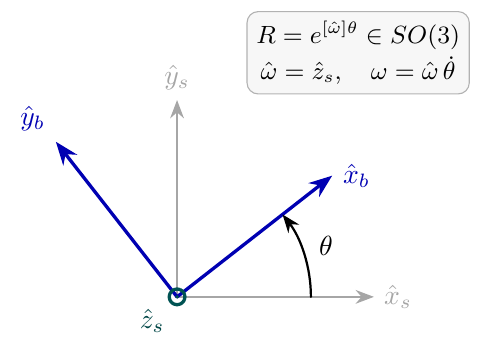

In [3]:
render_tikz_file("_figures/src/rotation_so3.tex", name="rotation_so3")

### Exponential coordinates: from an axis–angle to a rotation

Any rotation can be written as a rotation by an angle $\theta$ about a unit axis $\hat{\omega}$. Stacking these as $\hat{\omega}\theta\in\mathbb{R}^3$ gives the **exponential coordinates** of the rotation. The map back to a matrix is the matrix exponential of the skew-symmetric form $[\hat{\omega}]$ (Rodrigues' formula):

$$R=e^{[\hat{\omega}]\theta}\in SO(3).$$

In ManipulaPy: `VecToso3` builds the $3\times3$ skew matrix $[\,\cdot\,]$, `MatrixExp3` exponentiates it, and `MatrixLog3` inverts the map.

In [4]:
# Rotate 90 degrees about z: x_hat should map to y_hat.
omega_hat_theta = np.array([0, 0, np.pi / 2])      # axis * angle
so3 = VecToso3(omega_hat_theta)                    # 3x3 skew-symmetric matrix
R = MatrixExp3(so3)                                # Rodrigues' formula
print("R =\n", R)
print("R @ x_hat =", R @ np.array([1, 0, 0]), "(expect [0, 1, 0])")

# SO(3) membership: orthonormal and det = +1.
print("R^T R = I :", np.allclose(R.T @ R, np.eye(3)))
print("det(R)   :", round(float(np.linalg.det(R)), 6))

# Recover the exponential coordinates with the matrix log.
recovered = skew_symmetric_to_vector(MatrixLog3(R))
print("log(R)   =", recovered, "(expect [0, 0, %.4f])" % (np.pi / 2))

R =
 [[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]
R @ x_hat = [0. 1. 0.] (expect [0, 1, 0])
R^T R = I : True
det(R)   : 1.0
log(R)   = [0.     0.     1.5708] (expect [0, 0, 1.5708])


### `rotation_logm`: axis and angle directly

Often you want the **axis** and **angle** separately rather than the stacked vector $\hat{\omega}\theta$. `rotation_logm(R)` returns exactly $(\hat{\omega},\ \theta)$.

In [5]:
axis, angle = rotation_logm(R)
print("axis  =", axis, " angle =", round(float(angle), 4))
assert np.allclose(axis * angle, recovered, atol=1e-9)   # consistent with MatrixLog3

axis  = [0. 0. 1.]  angle = 1.5708


### The log is **not** a unique inverse

Exponentiation is many-to-one, so the matrix log must *choose* a representative:

- It returns the **principal angle** $\theta\in[0,\pi]$.
- The axis–angle pair is not unique: $(\hat{\omega},\theta)$, $(-\hat{\omega},-\theta)$, and $(\hat{\omega},\theta+2\pi k)$ all give the **same** $R$.
- At $\theta=\pi$ the axis is determined only up to sign (both $\pm\hat{\omega}$ are valid), a genuine singular case.
- For $R=I$ ($\theta=0$) the axis is undefined.

The same caveats apply to `MatrixLog6` for $SE(3)$: a **pure translation** has zero rotation, so its screw is a pure-translation twist (the rotational part vanishes and the “axis” is the translation direction).

Numerically, $\theta=\pi$ is the hard case: the log is **ill-conditioned** there, so the recovered angle carries small error and `MatrixLog3` can degrade. `rotation_logm` stays robust and is the recommended way to extract an axis–angle.

In [6]:
# Large rotation: 300 deg about z is reported as its principal equivalent.
R_big = MatrixExp3(VecToso3([0, 0, np.deg2rad(300)]))
axis_b, angle_b = rotation_logm(R_big)
print("input 300 deg -> principal angle %.1f deg about axis %s"
      % (np.rad2deg(angle_b), np.round(axis_b, 3)))
assert 0 <= angle_b <= np.pi + 1e-9               # principal angle in [0, pi]
assert np.allclose(MatrixExp3(VecToso3(axis_b * angle_b)), R_big)  # same rotation

# theta = pi: the singular case. The axis is defined only up to sign, and the
# log is ill-conditioned, so the recovered angle carries ~1e-8 error.
R_pi = MatrixExp3(VecToso3([0, 0, np.pi]))
ax_pi, ang_pi = rotation_logm(R_pi)
print("theta=pi: angle = %.10f, axis = %s (sign-ambiguous)" % (ang_pi, np.round(ax_pi, 3)))
print("angle error vs pi:", abs(ang_pi - np.pi))
# Reconstruction is only approximate here -- note the relaxed tolerance.
assert np.allclose(MatrixExp3(VecToso3(ax_pi * ang_pi)), R_pi, atol=1e-6)
print("rotation_logm stays robust at pi; use it rather than MatrixLog3, which\n"
      "degrades to a near-zero matrix at theta = pi.")

input 300 deg -> principal angle 60.0 deg about axis [ 0.  0. -1.]
theta=pi: angle = 3.1415926325, axis = [-0.  0.  1.] (sign-ambiguous)
angle error vs pi: 2.107342433887993e-08
rotation_logm stays robust at pi; use it rather than MatrixLog3, which
degrades to a near-zero matrix at theta = pi.


### Sidebar: Euler angles (and why we avoid them)

Euler angles parameterize a rotation with three scalars. ManipulaPy offers `euler_to_rotation_matrix` (ZYX) and its inverse. **Watch the units — they are asymmetric:** the forward map takes **degrees**, the inverse returns **radians**. Euler angles also suffer **gimbal lock** (a lost degree of freedom at pitch $=\pm90^\circ$), which is why screw/exponential coordinates are preferred throughout this course.

In [7]:
R_euler = euler_to_rotation_matrix([0, 0, 90])      # roll, pitch, yaw in DEGREES
print("euler [0,0,90] deg -> R @ x_hat =", R_euler @ np.array([1, 0, 0]))
back = rotation_matrix_to_euler_angles(R_euler)     # returns RADIANS
print("inverse -> %s rad  (= %s deg)" % (np.round(back, 4), np.round(np.rad2deg(back), 1)))
assert np.allclose(R_euler @ np.array([1, 0, 0]), [0, 1, 0], atol=1e-9)

euler [0,0,90] deg -> R @ x_hat = [0. 1. 0.]
inverse -> [ 0.     -0.      1.5708] rad  (= [ 0. -0. 90.] deg)


### Angular velocity: space vs body

When a frame rotates, $R=R(t)$ and its rate $\dot R$ encodes the **angular velocity**. There are two equally valid expressions, differing only in the frame they are written in:

$$[\omega_s]=\dot R\,R^\top \quad(\text{space frame}),\qquad [\omega_b]=R^\top\dot R \quad(\text{body frame}),$$

and the two are related by the rotation itself: $\omega_s = R\,\omega_b$. (Both $[\omega_s]$ and $[\omega_b]$ are skew-symmetric — recover the vector with `skew_symmetric_to_vector`.) We verify all three numerically below.

In [8]:
# A frame spinning at constant rate about a fixed unit axis.
w_hat = np.array([1.0, 2.0, 2.0]); w_hat /= np.linalg.norm(w_hat)
theta_dot = 0.7
def R_of_t(t):
    return MatrixExp3(VecToso3(w_hat * theta_dot * t))

t0, h = 0.4, 1e-6
R0 = R_of_t(t0)
Rdot = (R_of_t(t0 + h) - R_of_t(t0 - h)) / (2 * h)     # finite-difference dR/dt

omega_s = skew_symmetric_to_vector(Rdot @ R0.T)        # [w_s] = Rdot R^T
omega_b = skew_symmetric_to_vector(R0.T @ Rdot)        # [w_b] = R^T Rdot
print("omega_s =", omega_s, " (expect w_hat*theta_dot =", np.round(w_hat * theta_dot, 4), ")")
print("omega_b =", omega_b)

assert np.allclose(omega_s, w_hat * theta_dot, atol=1e-4)   # space velocity = axis*rate
assert np.allclose(omega_s, R0 @ omega_b, atol=1e-4)        # omega_s = R omega_b

omega_s = [0.2333 0.4667 0.4667]  (expect w_hat*theta_dot = [0.2333 0.4667 0.4667] )
omega_b = [0.2333 0.4667 0.4667]


## 2. Rigid-body motions and $SE(3)$

A full rigid-body configuration is a rotation **and** a translation, packed into a $4\times4$ **homogeneous transformation matrix**

$$T=\begin{bmatrix}R & p\\ 0 & 1\end{bmatrix}\in SE(3),\qquad R\in SO(3),\ p\in\mathbb{R}^3.$$

These compose by matrix multiplication and invert in closed form ($T^{-1}=\begin{bmatrix}R^\top & -R^\top p\\ 0 & 1\end{bmatrix}$). ManipulaPy gives `TransToRp` (split $T$ into $R,p$) and `TransInv` (the closed-form inverse).

In [9]:
p = np.array([0.3, -0.1, 0.5])
T = np.eye(4)
T[:3, :3] = R
T[:3, 3] = p
print("T =\n", T)

R_back, p_back = TransToRp(T)
print("split ok:", np.allclose(R_back, R) and np.allclose(p_back, p))

# Closed-form inverse undoes the transform.
print("T^{-1} T = I :", np.allclose(TransInv(T) @ T, np.eye(4)))

T =
 [[ 0.  -1.   0.   0.3]
 [ 1.   0.   0.  -0.1]
 [ 0.   0.   1.   0.5]
 [ 0.   0.   0.   1. ]]
split ok: True
T^{-1} T = I : True


## 3. Screw axes and twists

By the **Chasles–Mozzi theorem**, every rigid-body motion is a rotation about some axis combined with a translation along that same axis — a **screw motion**. The screw axis is described by:

- a unit direction $\hat{s}$ along the axis,
- a point $q$ the axis passes through,
- a **pitch** $h$ = (linear speed)/(angular speed) along the axis.

The instantaneous motion is a **twist** $\mathcal{V}=[\omega;\,v]$, where $\omega$ is the angular velocity and $v$ is the twist's **linear component** (the two parts together describe the rigid-body velocity field). For motion about the screw at rate $\dot{\theta}$:

$$\mathcal{V}=\begin{bmatrix}\omega\\ v\end{bmatrix}=\begin{bmatrix}\hat{s}\,\dot{\theta}\\ (-\hat{s}\times q + h\,\hat{s})\,\dot{\theta}\end{bmatrix}.$$

A twist, like an angular velocity, is **frame-dependent**. The same physical motion has a **space twist** $\mathcal{V}_s$ (expressed in the fixed frame) and a **body twist** $\mathcal{V}_b$ (expressed in the moving body frame). Only in the space frame does $v$ coincide with the velocity of the (possibly imaginary) body point instantaneously at the origin; in general $v$ is just the linear part of the twist. The two are related by the adjoint, $\mathcal{V}_s=[\mathrm{Ad}_{T_{sb}}]\,\mathcal{V}_b$ — which we use in Section 5 and again for Jacobians in notebook 03.

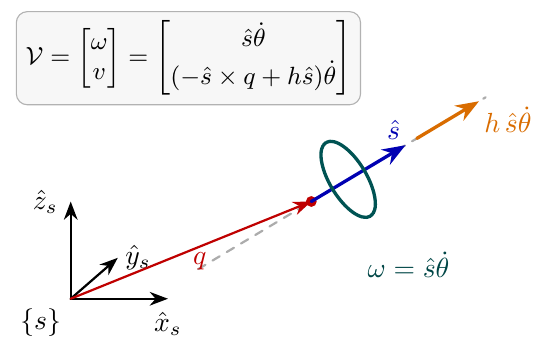

In [10]:
render_tikz_file("_figures/src/screw_axis.tex", name="screw_axis")

A **revolute joint** is the special case of zero pitch ($h=0$): the linear part is purely $v=-\hat{s}\times q$. We build such a screw below — this is exactly the form the Panda's joint screw axes take in the next notebook.

In [11]:
s_hat = np.array([0.0, 0.0, 1.0])      # axis direction (z)
q = np.array([0.3, 0.0, 0.0])          # a point on the axis
v = -np.cross(s_hat, q)                 # zero-pitch (revolute) linear part
S = np.concatenate([s_hat, v])         # the 6-vector screw axis [omega; v]
print("screw axis S =", S)

# [V] in se(3) is the 4x4 matrix form, via VecTose3; se3ToVec inverts it.
se3 = VecTose3(S)
print("se3ToVec(VecTose3(S)) == S :", np.allclose(se3ToVec(se3), S))

screw axis S = [ 0.   0.   1.  -0.  -0.3 -0. ]
se3ToVec(VecTose3(S)) == S : True


## 4. Exponential coordinates for rigid-body motion

Just as $e^{[\hat{\omega}]\theta}$ turns an axis–angle into a rotation, the $4\times4$ matrix exponential $e^{[\mathcal{S}]\theta}$ turns a screw axis $\mathcal{S}$ followed for an angle $\theta$ into a rigid-body transform $T\in SE(3)$. This single operation is the engine behind the **Product of Exponentials** forward-kinematics formula in notebook 02.

`MatrixExp6` takes the $4\times4$ matrix $[\mathcal{S}]\theta$; `MatrixLog6` recovers it.

In [12]:
theta = np.pi / 2
T_screw = MatrixExp6(VecTose3(S * theta))    # follow the screw S by theta
print("T(theta) =\n", T_screw)

# The zero twist gives the identity transform.
print("exp(0) == I :", np.allclose(MatrixExp6(VecTose3(np.zeros(6))), np.eye(4)))

# Round trip: log of the transform recovers the original screw * theta.
recovered = se3ToVec(MatrixLog6(T_screw))
print("log(exp(S*theta)) == S*theta :", np.allclose(recovered, S * theta))

T(theta) =
 [[ 0.  -1.   0.   0.3]
 [ 1.   0.   0.  -0.3]
 [ 0.   0.   1.   0. ]
 [ 0.   0.   0.   1. ]]
exp(0) == I : True
log(exp(S*theta)) == S*theta : True


### `transform_from_twist`: the same thing, in one call

ManipulaPy bundles “build $[\mathcal{S}]\theta$ then exponentiate” into `transform_from_twist(S, theta)`. It is exactly $e^{[\mathcal{S}]\theta}$ — verified here for a **revolute** screw (zero pitch) and a **prismatic** screw (pure translation, $\omega=0$).

In [13]:
# Revolute: zero-pitch screw about z through q.
S_rev = np.concatenate([[0, 0, 1], -np.cross([0, 0, 1], [0.3, 0, 0])])
assert np.allclose(transform_from_twist(S_rev, np.pi / 2),
                   MatrixExp6(VecTose3(S_rev * (np.pi / 2))))

# Prismatic: pure translation along y (omega = 0, v = y_hat).
S_pris = np.array([0, 0, 0, 0, 1, 0], float)
T_pris = transform_from_twist(S_pris, 0.5)
print("prismatic translation =", T_pris[:3, 3], "(expect [0, 0.5, 0])")
assert np.allclose(T_pris[:3, 3], [0, 0.5, 0])
assert np.allclose(T_pris[:3, :3], np.eye(3))      # no rotation
assert np.allclose(transform_from_twist(S_pris, 0.5),
                   MatrixExp6(VecTose3(S_pris * 0.5)))

prismatic translation = [0.  0.5 0. ] (expect [0, 0.5, 0])


### Watching a screw motion in simulation

The corkscrew picture is easier to believe when a body actually follows it. ManipulaPy's **simulation module** (`ManipulaPy.sim.Simulation`) wraps PyBullet; here we run it **headless** (`MANIPULAPY_PYBULLET_CONNECT=DIRECT`, so this also works on Colab and CI) and use its camera to photograph the scene. We sweep $\theta$, place a small block at $T(\theta)=e^{[\mathcal{S}]\theta}\,T_0$, and trace the path with `plot_trajectory`, which draws it as real geometry the camera can see.

With pitch $h=0.1$ the screw is a true corkscrew: the block circles the axis while climbing $h\,\theta$ along it.

In [14]:
import os
os.environ.setdefault("MANIPULAPY_PYBULLET_CONNECT", "DIRECT")  # headless; remove to watch in a GUI
import logging
from helpers import sim_snapshot, quiet_pybullet
from ManipulaPy.sim import Simulation
import pybullet as p

with quiet_pybullet():
    sim = Simulation("cube_small.urdf", joint_limits=[])   # a lone block + ground plane
# Simulation's logger defaults to DEBUG; keep the notebook output clean.
logging.getLogger("SimulationLogger").setLevel(logging.WARNING)

h = 0.1                                       # pitch: metres advanced per radian
S_screw = np.concatenate([s_hat, -np.cross(s_hat, q) + h * s_hat])
T0 = np.eye(4); T0[:3, 3] = [0.0, 0.0, 0.15]  # block's start pose

thetas = np.linspace(0, 1.5 * np.pi, 60)
path = []
for th in thetas:
    Tt = transform_from_twist(S_screw, th) @ T0
    path.append(Tt[:3, 3])
    p.resetBasePositionAndOrientation(
        sim.robot_id, Tt[:3, 3],
        p.getQuaternionFromEuler(rotation_matrix_to_euler_angles(Tt[:3, :3])))

# Chasles in numbers: constant radius about the axis, climb = h * theta.
P = np.array(path)
radii = np.linalg.norm(P[:, :2] - q[:2], axis=1)
assert np.allclose(radii, radii[0], atol=1e-9)
assert np.allclose(P[:, 2] - P[0, 2], h * thetas, atol=1e-9)
print("screw path: radius constant at %.2f m, climb = h*theta (max %.3f m)"
      % (radii[0], h * thetas[-1]))

pybullet build time: Jan 29 2025 23:16:28


screw path: radius constant at 0.30 m, climb = h*theta (max 0.471 m)


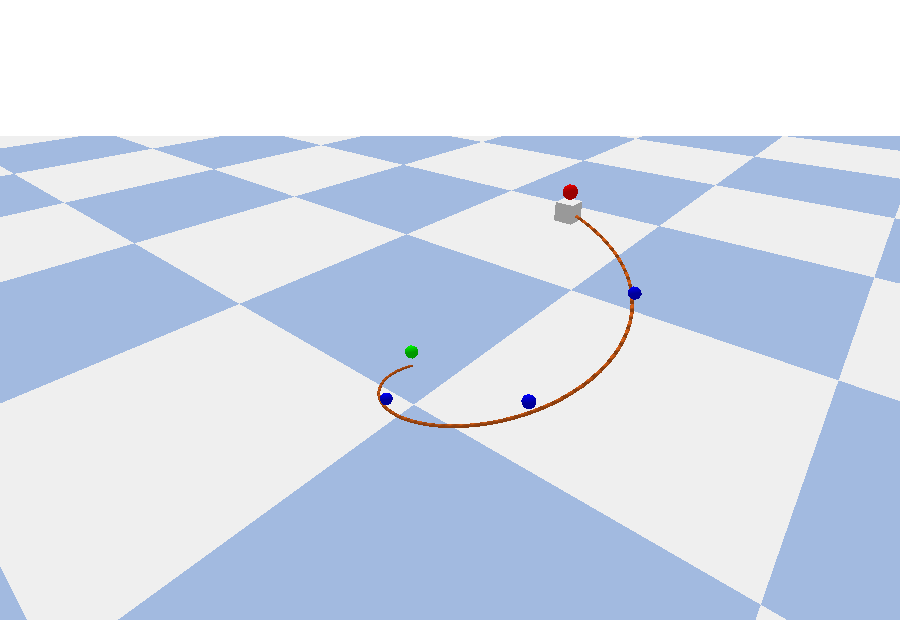

In [15]:
sim.plot_trajectory(path, color=[0.9, 0.4, 0.1])   # orange capsules + start/end markers
img = sim_snapshot("sim_screw_motion", target=(0.15, 0, 0.4), distance=1.4, yaw=40, pitch=-30)
sim.disconnect_simulation()
img

### Looking ahead: `extract_screw_list`

A serial robot is a *chain* of these screws — one per joint. `extract_screw_list(omega_list, r_list)` assembles the $6\times n$ matrix of joint screw axes from each joint's axis direction ($\omega$) and a point on it ($r$). That matrix is the input to the **Product of Exponentials** forward kinematics in notebook 02; here we just build a tiny 2-joint example.

In [16]:
# Two revolute joints: both about z, at x = 0 and x = 0.3.
omega_list = np.array([[0, 0], [0, 0], [1, 1]], float)   # 3 x n axis directions
r_list = np.array([[0.0, 0.3], [0, 0], [0, 0]], float)   # 3 x n points on axes
Slist = extract_screw_list(omega_list, r_list)
print("screw list (6 x 2):\n", Slist)
assert Slist.shape == (6, 2)
assert np.allclose(Slist[:3, 0], [0, 0, 1])              # first joint axis is z

screw list (6 x 2):
 [[ 0.   0. ]
 [ 0.   0. ]
 [ 1.   1. ]
 [ 0.   0. ]
 [ 0.  -0.3]
 [ 0.   0. ]]


## 5. The adjoint map

A twist is expressed in some frame. To re-express the **same** physical twist in another frame related by $T$, we use the $6\times6$ **adjoint** $[\mathrm{Ad}_T]$:

$$\mathcal{V}_a=[\mathrm{Ad}_{T_{ab}}]\,\mathcal{V}_b,\qquad [\mathrm{Ad}_T]=\begin{bmatrix}R & 0\\ [p]R & R\end{bmatrix}.$$

This is how joint screw axes get moved between the space frame and the body frame (notebook 03). ManipulaPy provides `adjoint_transform`.

In [17]:
Ad = adjoint_transform(T)
print("Ad_T shape:", Ad.shape)

# Re-express the screw twist in the transformed frame, then map it back.
V_b = S.copy()
V_a = Ad @ V_b
V_b_again = adjoint_transform(TransInv(T)) @ V_a
print("adjoint round trip recovers the twist :", np.allclose(V_b_again, V_b))

Ad_T shape: (6, 6)
adjoint round trip recovers the twist : True


## Smoke test

Asserts the key invariants of this notebook in one cell.

In [18]:
# Rotations
R = MatrixExp3(VecToso3([0, 0, np.pi / 2]))
assert np.allclose(R @ np.array([1, 0, 0]), [0, 1, 0], atol=1e-9)
assert np.allclose(R.T @ R, np.eye(3)) and np.isclose(np.linalg.det(R), 1.0)
# SE(3)
T = np.eye(4); T[:3, :3] = R; T[:3, 3] = [0.3, -0.1, 0.5]
assert np.allclose(TransInv(T) @ T, np.eye(4))
# Screw / exponential coordinates round trip
S = np.array([0, 0, 1, 0, -0.3, 0], float)
assert np.allclose(se3ToVec(MatrixLog6(MatrixExp6(VecTose3(S * 1.1)))), S * 1.1, atol=1e-9)
# Adjoint
assert adjoint_transform(T).shape == (6, 6)
# rotation_logm returns a unit axis and the principal angle
ax, ang = rotation_logm(R)
assert np.isclose(np.linalg.norm(ax), 1.0) and 0 <= ang <= np.pi + 1e-9
# transform_from_twist == MatrixExp6(VecTose3(.))
assert np.allclose(transform_from_twist(S, 0.9), MatrixExp6(VecTose3(S * 0.9)))
# extract_screw_list builds a 6xn matrix
assert extract_screw_list(np.array([[0],[0],[1]],float), np.array([[0.3],[0],[0]],float)).shape == (6, 1)
# Euler: degrees in, radians out
assert np.allclose(rotation_matrix_to_euler_angles(euler_to_rotation_matrix([0, 0, 90]))[2], np.pi / 2)
print("nb01 foundations: smoke OK")

nb01 foundations: smoke OK


## Try it

1. Build the rotation that takes $\hat{x}_s$ to $\hat{z}_s$ and verify it is in $SO(3)$. *(Hint: a $90^\circ$ rotation about $\hat{y}$.)*
2. Construct the screw axis of a **prismatic** joint sliding along $\hat{y}$ (pure translation: $\omega=0$, $v=\hat{y}$) and confirm `MatrixExp6` produces a pure-translation transform for a given displacement.
3. Take two transforms $T_1,T_2$ and check that $[\mathrm{Ad}_{T_1 T_2}] = [\mathrm{Ad}_{T_1}][\mathrm{Ad}_{T_2}]$.

*Next up — notebook 02: chaining screw exponentials into the **Product of Exponentials** forward-kinematics formula on the Panda.*

## References

1. K. M. Lynch and F. C. Park, *Modern Robotics: Mechanics, Planning, and Control*, Cambridge University Press, 2017. — The primary reference for this course; ManipulaPy follows its screw-theory / Product-of-Exponentials conventions. (Chapters 3 *Rigid-Body Motions* and 4 *Forward Kinematics*.)
2. R. M. Murray, Z. Li, and S. S. Sastry, *A Mathematical Introduction to Robotic Manipulation*, CRC Press, 1994. — Foundational treatment of twists, screws, and exponential coordinates.
3. B. Siciliano, L. Sciavicco, L. Villani, and G. Oriolo, *Robotics: Modelling, Planning and Control*, Springer, 2009.
4. ManipulaPy documentation — https://manipulapy.readthedocs.io/ · source — https://github.com/boelnasr/ManipulaPy
